In [1]:
# Cell 1: imports & style
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy import odr
from scipy.stats import spearmanr, pearsonr

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
# Cell 2: loader for one replicate file in your format
# Expected columns like:
# ID\tLineage s\tstderr(s)\tf0_array
# We'll be tolerant to minor name variations.

def _find_col(cols, candidates):
    cols_norm = {c.lower().strip(): c for c in cols}
    for cand in candidates:
        k = cand.lower().strip()
        if k in cols_norm:
            return cols_norm[k]
    return None

def load_replicate_tsv(path, rep_name):
    """Read one replicate table and return a minimal dataframe:
       ['ID', f's_{rep_name}', f'stderr_{rep_name}', 'f0_array'].
       If multiple f0 columns exist across reps, we keep the first seen later."""
    df = pd.read_csv(path, sep="\t")

    # locate columns
    id_col  = _find_col(df.columns, ["ID", "Id", "id"])
    s_col   = _find_col(df.columns, ["s", "Lineage s", "fitness", "Fitness", "fitness_s"])
    se_col  = _find_col(df.columns, ["stderr(s)", "stderr", "se", "stderr_s"])
    f0_col  = _find_col(df.columns, ["f0_array", "f0", "P0_freq", "p0_freq"])

    if id_col is None or s_col is None:
        raise ValueError(f"Could not find 'ID' or 's' column in {path}. Got columns: {list(df.columns)}")

    out = pd.DataFrame({
        "ID": df[id_col].astype(str),
        f"s_{rep_name}": pd.to_numeric(df[s_col], errors="coerce")
    })
    if se_col is not None:
        out[f"stderr_{rep_name}"] = pd.to_numeric(df[se_col], errors="coerce")
    if f0_col is not None:
        out["f0_array"] = pd.to_numeric(df[f0_col], errors="coerce")
    return out

In [4]:
# Cell 3: configure file paths and load
# Update these paths to your actual filenames
files = {
    "Rep1": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/P0/FMIC_e5/fitness_1_with_ids.tsv",
    "Rep2": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/P0/FMIC_e5/fitness_2_with_ids.tsv",
    "Rep3": "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/P0/FMIC_e5/fitness_3_with_ids.tsv",
    # add/remove as needed
}

# load and merge on ID (inner join = only IDs present in all chosen reps)
merged = None
for rep, path in files.items():
    df_rep = load_replicate_tsv(path, rep)
    merged = df_rep if merged is None else merged.merge(df_rep, on="ID", how="inner")

# Optional: filter by P0 frequency and/or stderr thresholds
# Choose one f0 column source; if present from multiple, the last load overwrote it — that’s fine.
F0_MIN = 1e-5         # <- adjust or set to None to skip
MAX_STDERR = None     # e.g., 150.0 or None to skip

if "f0_array" in merged.columns and F0_MIN is not None:
    merged = merged.loc[merged["f0_array"] >= F0_MIN].copy()

if MAX_STDERR is not None:
    se_cols = [c for c in merged.columns if c.startswith("stderr_")]
    if se_cols:
        merged = merged.loc[(merged[se_cols] <= MAX_STDERR).all(axis=1)].copy()

# Keep only finite values for selected replicate pair later
print(f"Merged rows: {len(merged)}")
merged.head()

Merged rows: 27620


,ID,s_Rep1,stderr_Rep1,f0_array_x,s_Rep2,stderr_Rep2,f0_array_y,s_Rep3,stderr_Rep3,f0_array
0,66434,-1.449042,1.674116e+06,0.000072,-1.496895,559969.731413,0.000072,-1.426209,492038.720278,0.000072
1,82167,-1.430086,3.022469e+06,0.000019,-1.334975,620845.578018,0.000019,-1.254806,524841.477733,0.000019
2,81289,-1.425575,1.742065e+06,0.000056,-1.422070,488645.830173,0.000056,-1.135991,204320.549586,0.000056
3,64609,-1.411680,2.431548e+06,0.000026,-1.316226,498993.193097,0.000026,-1.194096,363852.897856,0.000026
4,25347,-1.407754,2.590154e+06,0.000022,-1.416248,756480.046465,0.000022,-1.290695,551275.975399,0.000022


In [26]:
# Cell 4: choose replicate pair for fitting
x_rep = "Rep1"   # x-axis replicate
y_rep = "Rep3"   # y-axis replicate

x_col = f"s_{x_rep}"
y_col = f"s_{y_rep}"

xy = merged[["ID", x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
x = xy[x_col].to_numpy()
y = xy[y_col].to_numpy()
print(f"N pairs for {y_rep} vs {x_rep}: {len(x)}")
xy.head()

N pairs for Rep3 vs Rep1: 27620


,ID,s_Rep1,s_Rep3
0,66434,-1.449042,-1.426209
1,82167,-1.430086,-1.254806
2,81289,-1.425575,-1.135991
3,64609,-1.411680,-1.194096
4,25347,-1.407754,-1.290695


In [27]:
# Cell 5: model families (flexible + saturating options)

def cubic(x, a, b, c, d):
    return a + b*x + c*x**2 + d*x**3

def tanh_model(x, A, B, C, D):
    # A * tanh(B*x + C) + D
    return A * np.tanh(B*x + C) + D

def logistic_model(x, L, k, x0, C):
    # C + L / (1 + exp(-k*(x - x0)))
    return C + L / (1.0 + np.exp(-k*(x - x0)))

def michaelis_menten_signed(x, V, K, C):
    # y = C + V * x / (K + |x|)
    return C + V * (x / (K + np.abs(x) + 1e-12))

In [28]:
# Cell 6: fit & compare
from math import isfinite

def fit_with_curve_fit(func, x, y, p0=None, bounds=(-np.inf, np.inf)):
    try:
        popt, pcov = curve_fit(func, x, y, p0=p0, bounds=bounds, maxfev=100000)
        yhat = func(x, *popt)
        resid = y - yhat
        rmse = np.sqrt(np.mean(resid**2))
        ss_res = np.sum(resid**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        k = len(popt); n = len(x)
        aic = n*np.log(ss_res/n) + 2*k if n > 0 and ss_res > 0 else np.nan
        return {"ok": True, "popt": popt, "rmse": rmse, "r2": r2, "aic": aic, "yhat": yhat}
    except Exception as e:
        return {"ok": False, "error": repr(e)}

# Heuristic initial guesses
p0s = {
    cubic: (0, 1, 0, 0),
    tanh_model: ((y.max()-y.min())/2, 1.0/(np.std(x)+1e-6), 0.0, y.mean()),
    logistic_model: ((y.max()-y.min()), 5.0/(np.std(x)+1e-6), np.median(x), y.min()),
    michaelis_menten_signed: ((y.max()-y.min()), np.std(x) if np.std(x)>0 else 1.0, y.mean())
}

models = {
    "cubic": cubic,
    "tanh": tanh_model,
    "logistic": logistic_model,
    "MM_signed": michaelis_menten_signed
}

results = {name: fit_with_curve_fit(f, x, y, p0=p0s.get(f, None)) for name, f in models.items()}

summary = (
    pd.DataFrame({
        "model": list(results.keys()),
        "ok": [results[k]["ok"] for k in results],
        "RMSE": [results[k].get("rmse", np.nan) for k in results],
        "R2": [results[k].get("r2", np.nan) for k in results],
        "AIC": [results[k].get("aic", np.nan) for k in results],
    })
    .sort_values(["AIC", "RMSE"])
    .reset_index(drop=True)
)
summary

,model,ok,RMSE,R2,AIC
0,cubic,True,0.063771,0.794019,-152037.502253
1,logistic,True,0.066054,0.779009,-150094.858535
2,tanh,True,0.066054,0.779009,-150094.858521
3,MM_signed,True,0.075125,0.714143,-142988.243999


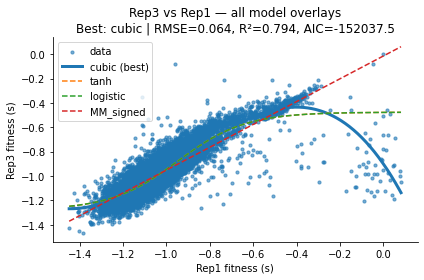

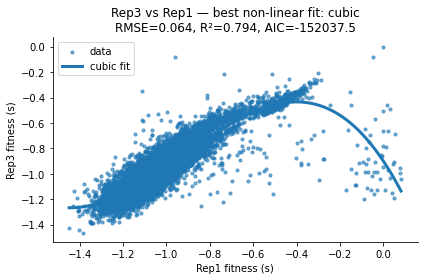

Best model: cubic
Parameters: [-0.89854681 -2.55138214 -4.06688778 -1.4701196 ]
Saved plot to: nonlinear_fit_Rep3_vs_Rep1_cubic.png


In [29]:
# Cell 7 (updated): plot ALL models for comparison, but SAVE ONLY the best model

# --- pick best by AIC ---
best_name = summary.loc[0, "model"]
best_func = models[best_name]
best = results[best_name]
popt_best = best["popt"]

# a common x-grid for smooth curves
xs = np.linspace(x.min(), x.max(), 400)

# 1) SHOW: overlay all model fits (not saved)
plt.figure()
plt.scatter(x, y, s=10, alpha=0.6, label="data")

for name, func in models.items():
    r = results[name]
    if not r["ok"]:
        continue
    ys_m = func(xs, *r["popt"])
    # emphasize the best curve
    if name == best_name:
        plt.plot(xs, ys_m, lw=3, label=f"{name} (best)")
    else:
        plt.plot(xs, ys_m, lw=1.5, linestyle="--", label=name)

plt.xlabel(f"{x_rep} fitness (s)")
plt.ylabel(f"{y_rep} fitness (s)")
plt.title(f"{y_rep} vs {x_rep} — all model overlays\n"
          f"Best: {best_name} | RMSE={best['rmse']:.3f}, R²={best['r2']:.3f}, AIC={best['aic']:.1f}")
plt.legend()
plt.tight_layout()
plt.show()  # <- only display, do not save

# 2) SAVE: figure with ONLY the best model
ys_best = best_func(xs, *popt_best)

plt.figure()
plt.scatter(x, y, s=10, alpha=0.6, label="data")
plt.plot(xs, ys_best, lw=3, label=f"{best_name} fit")
plt.xlabel(f"{x_rep} fitness (s)")
plt.ylabel(f"{y_rep} fitness (s)")
plt.title(f"{y_rep} vs {x_rep} — best non-linear fit: {best_name}\n"
          f"RMSE={best['rmse']:.3f}, R²={best['r2']:.3f}, AIC={best['aic']:.1f}")
plt.legend()
plt.tight_layout()
outfile = f"nonlinear_fit_{y_rep}_vs_{x_rep}_{best_name}.png"
plt.savefig(outfile, dpi=300)
plt.show()

print("Best model:", best_name)
print("Parameters:", popt_best)
print("Saved plot to:", outfile)

In [ ]:
# Cell 8 (OPTIONAL): ODR overlay and residual diagnostics
def odr_wrap(beta, x):
    return best_func(x, *beta)

sx = np.full_like(x, fill_value=np.std(x) * 0.02 + 1e-6)
sy = np.full_like(y, fill_value=np.std(y) * 0.02 + 1e-6)

model = odr.Model(odr_wrap)
data = odr.RealData(x, y, sx=sx, sy=sy)
odr_inst = odr.ODR(data, model, beta0=popt)
out = odr_inst.run()
beta_odr = out.beta

xs = np.linspace(x.min(), x.max(), 400)
ys_odr = best_func(xs, *beta_odr)

plt.figure()
plt.scatter(x, y, s=10, alpha=0.6, label="data")
plt.plot(xs, best_func(xs, *popt), lw=2, label=f"{best_name} (curve_fit)")
plt.plot(xs, ys_odr, lw=2, ls="--", label=f"{best_name} (ODR)")
plt.xlabel(f"{x_rep} fitness (s)")
plt.ylabel(f"{y_rep} fitness (s)")
plt.title(f"{y_rep} vs {x_rep} — {best_name}: curve_fit vs ODR")
plt.legend()
plt.tight_layout()
plt.show()

# correlations & residuals
pear = pearsonr(x, y)[0]
spear = spearmanr(x, y).correlation
resid = y - best_func(x, *popt)
print(f"Pearson R:  {pear:.3f}")
print(f"Spearman ρ: {spear:.3f}")
print(f"RMSE (curve_fit): {np.sqrt(np.mean(resid**2)):.3f}")

plt.figure()
plt.scatter(best_func(x, *popt), resid, s=10, alpha=0.6)
plt.axhline(0, lw=1)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()